<a href="https://colab.research.google.com/github/pravrud/CODESOFT_TASK1/blob/main/Movie_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(18,8)},style='darkgrid')
from time import time
import re
import string
import nltk

#from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import *
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#COLLECTION OF DATA
train = pd.read_csv(r"train_data.txt",sep=':::',names=['Title','Genre','Description']).reset_index(drop=True)
train.head()

,Title,Genre,Description
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [ ]:
test = pd.read_csv(r"test_data.txt",sep=':::',names=['Title','Description']).reset_index(drop=True)
test.head()

,Title,Description
0,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apar..."
1,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty ch..."
2,Off the Beaten Track (2010),One year in the life of Albin and his family ...
3,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with hi..."
4,Er nu zhai (1955),Before he was known internationally as a mart...


In [ ]:
train.describe(include='object')

,Title,Genre,Description
count,54214,54214,54214
unique,54214,27,54086
top,Nature's Fury: Storm of the Century (2006),drama,Grammy - music award of the American academy ...
freq,1,13613,12


In [ ]:
train.info

<bound method DataFrame.info of                                               Title          Genre  \
0                     Oscar et la dame rose (2009)          drama    
1                                     Cupid (1997)       thriller    
2                 Young, Wild and Wonderful (1980)          adult    
3                            The Secret Sin (1915)          drama    
4                           The Unrecovered (2007)          drama    
...                                             ...            ...   
54209                              "Bonino" (1953)         comedy    
54210                  Dead Girls Don't Cry (????)         horror    
54211    Ronald Goedemondt: Ze bestaan echt (2008)    documentary    
54212                     Make Your Own Bed (1944)         comedy    
54213   Nature's Fury: Storm of the Century (2006)        history    

                                             Description  
0       Listening in to a conversation between his do...  
1       A brother and sister with a past incestuous r...  
2       As the bus empties the students for their fie...  
3       To help their unemployed father make ends mee...  
4       The film's title refers not only to the un-re...  
...                                                  ...  
54209   This short-lived NBC live sitcom centered on ...  
54210   The NEXT Generation of EXPLOITATION. The sist...  
54211   Ze bestaan echt, is a stand-up comedy about g...  
54212   Walter and Vivian live in the country and hav...  
54213   On Labor Day Weekend, 1935, the most intense ...  

[54214 rows x 3 columns]>

In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
train.Genre.unique()

array([' drama ', ' thriller ', ' adult ', ' documentary ', ' comedy ',
       ' crime ', ' reality-tv ', ' horror ', ' sport ', ' animation ',
       ' action ', ' fantasy ', ' short ', ' sci-fi ', ' music ',
       ' adventure ', ' talk-show ', ' western ', ' family ', ' mystery ',
       ' history ', ' news ', ' biography ', ' romance ', ' game-show ',
       ' musical ', ' war '], dtype=object)

In [ ]:
test.describe(include='object')

,Title,Description
count,54200,54200
unique,54200,54072
top,Curitiba Zero Grau (2010),Grammy - music award of the American academy ...
freq,1,10


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54200 entries, 0 to 54199
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        54200 non-null  object
 1   Description  54200 non-null  object
dtypes: object(2)
memory usage: 847.0+ KB


In [ ]:
test.duplicated().sum()

np.int64(0)

In [ ]:
train.loc[train['Description'].str.contains(r'@\S+')].head()

,Title,Genre,Description
242,Túlvilági beszélö (1992),documentary,Mail <svaradi@sprynet.com> for translation. T...
1880,Rokonok (1954),drama,Mail <svaradi@sprynet.com> for translation. F...
1986,Lila akác (1934),comedy,Mail <svaradi@sprynet.com> for translation. S...
6579,A csúnya lány (1935),comedy,Mail <svaradi@sprynet.com> for translation. D...
8296,Füszer és csemege (1940),drama,Mail <svaradi@sprynet.com> for translation. 5...


In [ ]:
def detect_bhasha(text):
  try:
    return pycountry.languages.get(alpha_2=detect(text)).name.lower()
  except:
    return "unknown"
train['Language'] = test['Description'].apply(detect_bhasha)
test['Language'] = test['Description'].apply(detect_bhasha)
train.head()

,Title,Genre,Description,Language
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...,unknown
1,Cupid (1997),thriller,A brother and sister with a past incestuous r...,unknown
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...,unknown
3,The Secret Sin (1915),drama,To help their unemployed father make ends mee...,unknown
4,The Unrecovered (2007),drama,The film's title refers not only to the un-re...,unknown


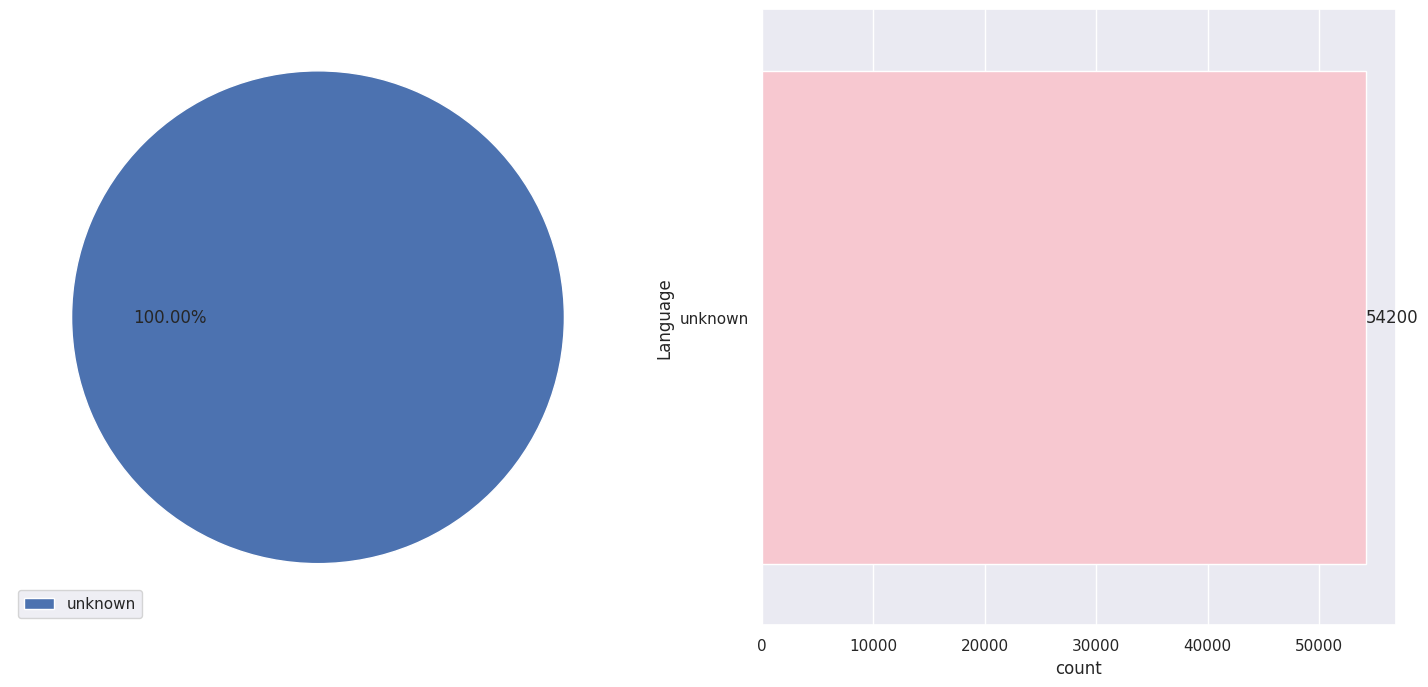

In [ ]:
fig,axs = plt.subplots(1,2)
axs[0].pie(train.Language.value_counts().values.tolist(),autopct='%.2f%%')
axs[0].legend(labels=train.Language.value_counts().index.tolist(),loc='lower left')
sns.countplot(data=train, y='Language',order=train.Language.value_counts().index,ax=axs[1],color='pink')
axs[1].bar_label(axs[1].containers[0])
plt.show()

In [ ]:
train.loc[train['Description'].str.contains(r'http\s+')].shape[0]

0

In [ ]:
train.loc[train['Description'].str.contains(r'http\S+')].head()['Description'].iloc[1]

" There's more to the story of the Clintons and 9/11. Over two nights -- September 10-11, 2006, just four months before Hillary announced the exploratory committee for her original presidential campaign, ABC aired The Path to 9/11, a riveting and factual docudrama. This acclaimed and balanced movie faulted two administrations -- Bill Clinton and George W. Bush. But fairness was not what Hillary wanted. Screenwriter Cyrus Nowrasteh told me he had expected the customary DVD distribution. But the Clintons, fearing the impact of DVD release during her campaign, successfully pressured Disney, which owns ABC, to bury the movie. This is a portion of a news article that originally appeared: http://www.frontpagemag.com/fpm/261541/hillarys-path-back-911-arnold-steinberg This article originally appeared in The Huffington Post http://www.huffingtonpost.com/arnold-steinberg/hillarys-path-back-to-911_b_9039658.html This article was written by Arnold Steinberg from Huffington Post and was legally lic

In [ ]:
def clean_text(text):
  text = re.sub('Mail <svaradi@sprynet.com> for translation. ', '',text)
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'http\S+', '', text)
  text = re.sub(f'[{string.punctuation}]','',text)
  text = re.sub(f'[{string.digits}]','',text)
  text =re.sub(r'\s+[a-zA-Z]\s+',' ', text)
  return text

In [ ]:
train['Description'] = train['Description'].apply(clean_text)
test['Description'] = test['Description'].apply(clean_text)

In [ ]:
train[~train.Language.isin(['english'])]

,Title,Genre,Description,Language
0,Oscar et la dame rose (2009),drama,Listening in to conversation between his doct...,unknown
1,Cupid (1997),thriller,brother and sister with past incestuous relat...,unknown
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...,unknown
3,The Secret Sin (1915),drama,To help their unemployed father make ends mee...,unknown
4,The Unrecovered (2007),drama,The films title refers not only to the unreco...,unknown
...,...,...,...,...
54209,"""Bonino"" (1953)",comedy,This shortlived NBC live sitcom centered on B...,NaN
54210,Dead Girls Don't Cry (????),horror,The NEXT Generation of EXPLOITATION The siste...,NaN
54211,Ronald Goedemondt: Ze bestaan echt (2008),documentary,Ze bestaan echt is standup comedy about growi...,NaN
54212,Make Your Own Bed (1944),comedy,Walter and Vivian live in the country and hav...,NaN


In [ ]:
def trans(text):
  try:
    return Translator().translate(text,dest='en').text
  except:
    return text
train.loc[~train['Language'].isin(['english']),'Description'] = train.loc[~train['Language'].isin(['english']),'Description'].apply(trans)
test.loc[~test['Language'].isin(['english']),'Description'] = test.loc[~test['Language'].isin(['english']),'Description'].apply(trans)


In [ ]:
train.drop(columns=['Language'],inplace=True)
test.drop(columns=['Language'],inplace=True)

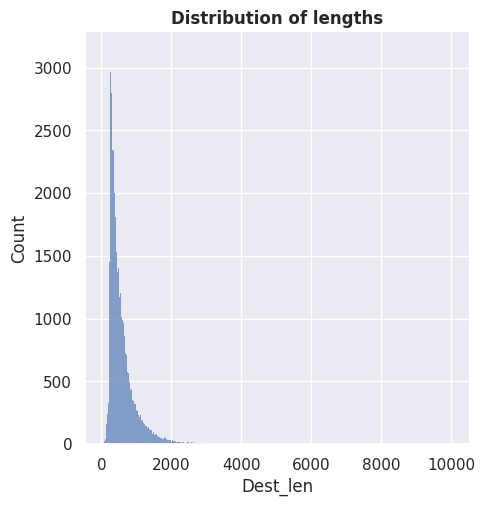

In [ ]:
train['Dest_len'] = train['Description'].apply(len)
sns.displot(train['Dest_len'])
plt.title('Distribution of lengths',fontweight='bold')
plt.show()

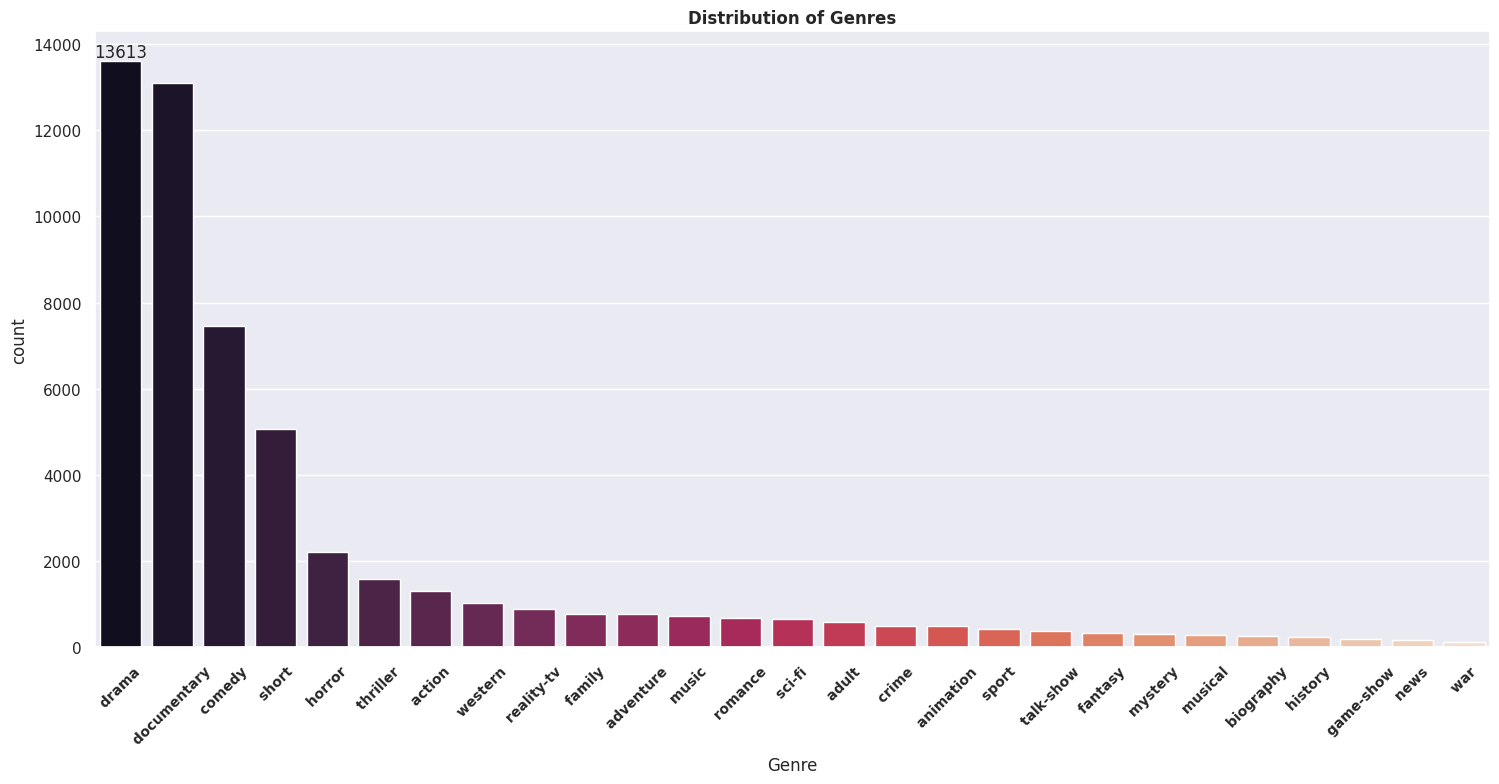

In [ ]:
ax=sns.countplot(data=train,x='Genre',order=train.Genre.value_counts().index,palette='rocket')
ax.bar_label(ax.containers[0])
plt.title('Distribution of Genres',fontweight='bold')
plt.xticks(rotation=45,fontweight='bold',fontsize=10)
plt.show()

In [ ]:
tfidf_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,1), stop_words='english', min_df=2)
x_train = tfidf_vectorizer.fit_transform(train['Description'])
x_test = tfidf_vectorizer.transform(test['Description'])

In [ ]:
sampler = RandomOverSampler()
x_train_resampled ,y_train_resampled = sampler.fit_resample(x_train,train['Genre'])

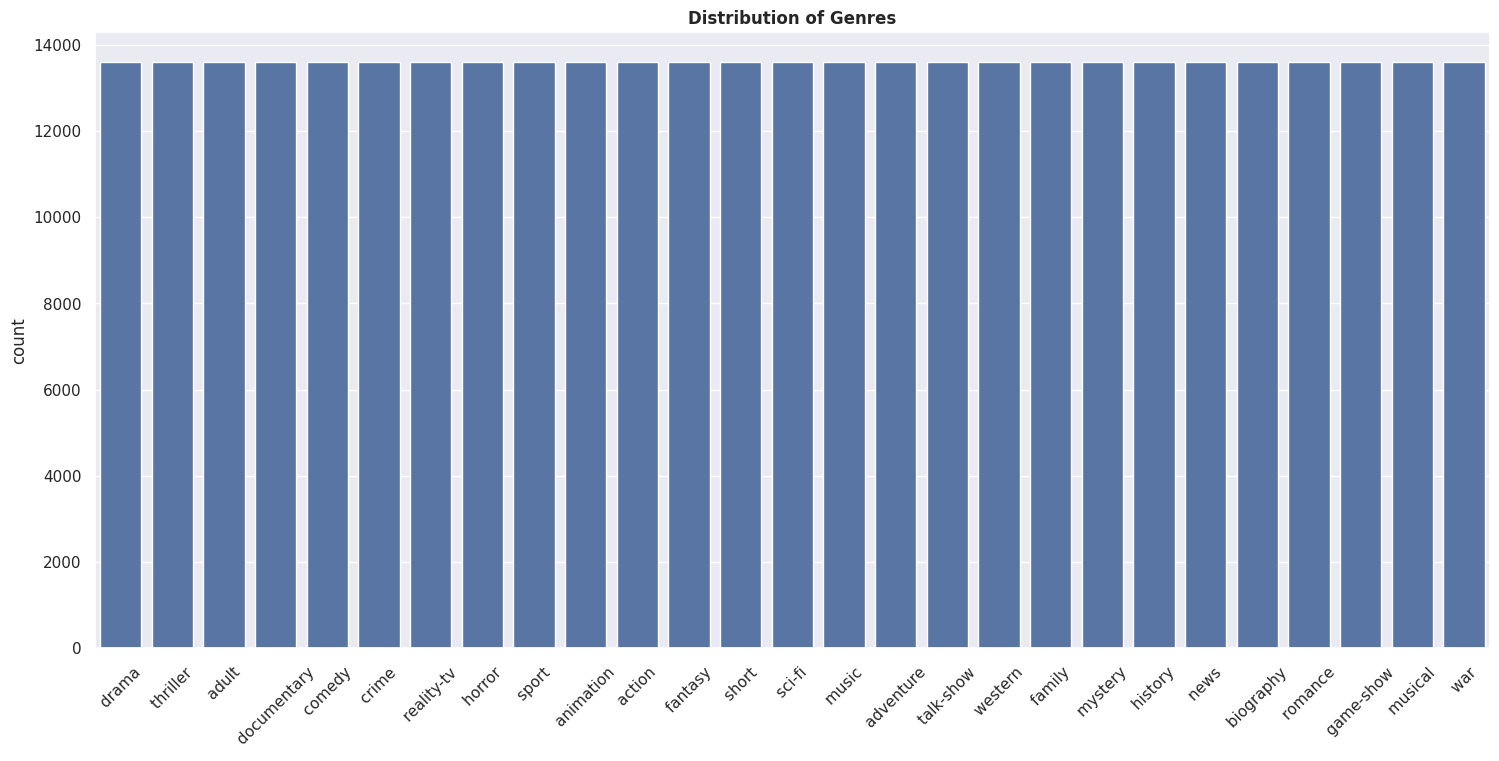

In [ ]:
sns.countplot(data = pd.DataFrame(y_train_resampled),x = y_train_resampled.values)
plt.title('Distribution of Genres',fontweight='bold')
plt.xticks(rotation = 45)
plt.show()

In [ ]:
y_actual = pd.read_csv(r"test_data_solution.txt",sep=':::', usecols=[2], header=None).rename(columns={2:'Actual_Genre'})
y_actual.head()

,Actual_Genre
0,thriller
1,comedy
2,documentary
3,drama
4,drama
